# Pokemon Data Analysis

For Applied AI

Created by Group Vinland:
- Hertz Lenin C. Miscreola
- Veneerick Joel C. Ondon



## 1. Setup

Run `python -m pip install pandas numpy seaborn matplotlib scikit-learn statsmodels mlxtend`

In [27]:
import os

import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
from sklearn.preprocessing import  StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from scipy import stats

In [34]:
path = "pokemon_complete_stats.csv"
df = pd.read_csv(path)

stat_cols = ['hp', 'attack', 'defense', 'special_attack', 'special_defense', 'speed']
df['bst'] = df[stat_cols].sum(axis=1)
df['stat_std'] = df[stat_cols].std(axis=1)


gen_map = {
    'generation-i': 1, 'generation-ii': 2, 'generation-iii': 3,
    'generation-iv': 4, 'generation-v': 5, 'generation-vi': 6,
    'generation-vii': 7, 'generation-viii': 8, 'generation-ix': 9
}
df['gen_num'] = df['generation'].map(gen_map)

df_melted = df.melt(
    id_vars=['gen_num', 'name'],
    value_vars = stat_cols,
    var_name = 'stat_type',
    value_name = 'stat_value'
)

df_melted['stat_type'] = (
    df_melted['stat_type'].str.replace('_', ' ').str.title()
)

df_standard = df[(df['is_legendary'] == False) & (df['is_mythical'] == False)]

sns.set_theme(style="whitegrid")

## 1. Power Creep Analysis and Generational Stat Shift Analysis

To evaluate whether total combat capability increased over time we utilized Generational Box Plots to analyze the distribution of Base Stat Total (BST).

We could stop at just plotting out the BST, but what makes a pokemon "strong" is how their stats are allocated.
After all, a Pokémon with balanced stats ($80/80/80/80/80/80 = 480\text{ BST}$) has the same total as a heavily min-maxed Pokémon ($150/150/30/30/30/90 = 480\text{ BST}$).

Pokemon is a game about fully utilizing your pokemon's strengths, min-maxxing allows them to focus solely on their strengths and not bother with anything else. Hence, min-maxxed pokemons are generally stronger than balanced pokemons. An example for this is that a Tank Blissey whose stats are all allocated to defense will be better at tanking hits than a Blissey whose half the stats are split into attack.

=== LINEAR REGRESSION RESULTS OF BST PER GENERATION ===
Slope:	+4.75 BST per generation
R²:	0.0139
P-Val:	0.0000


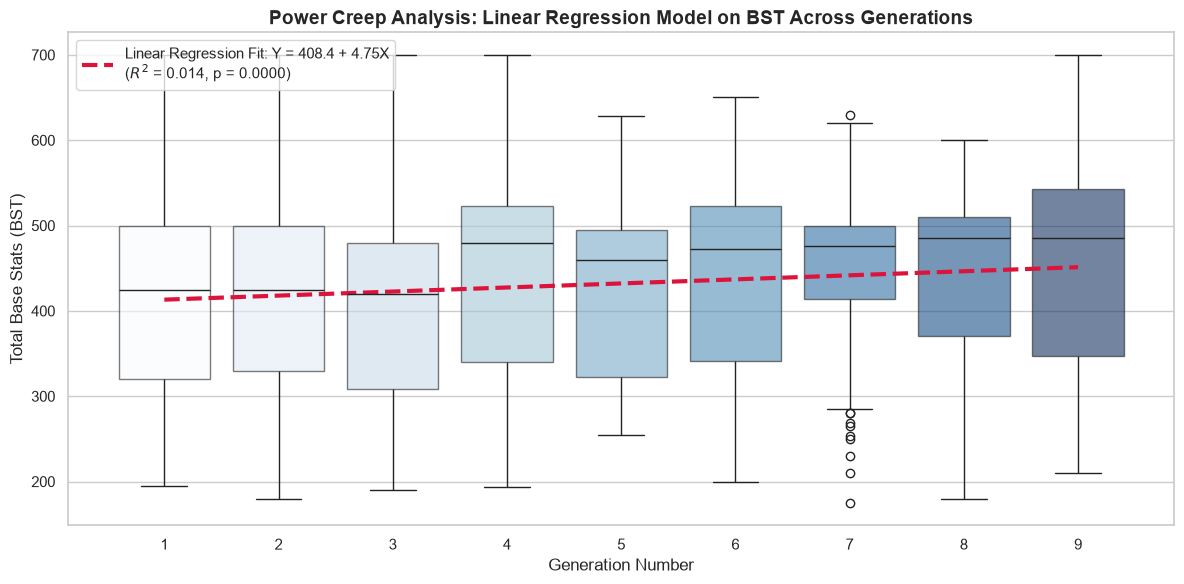

In [45]:
# Code for BST vs. Generation Number
x_vals = df_standard['gen_num']
y_vals = df_standard['bst']

slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, y_vals)

print(
    f'=== LINEAR REGRESSION RESULTS OF BST PER GENERATION ===\n'
    f'Slope:\t+{slope:.2f} BST per generation\n'
    f'R²:\t{r_value**2:.4f}\n'
    f'P-Val:\t{p_value:.4f}'
)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_standard,
    x='gen_num',
    y='bst',
    hue='gen_num',
    palette='Blues',
    legend=False,
    boxprops=dict(alpha=0.6),
    showfliers=True,
)

x_indexes = df_standard['gen_num'].unique() - 1
y_regression = intercept + slope * df_standard['gen_num'].unique()

plt.plot(
    x_indexes,
    y_regression,
    color='crimson',
    linewidth=3,
    linestyle='--',
    label=f'Linear Regression Fit: Y = {intercept:.1f} + {slope:.2f}X\n($R^2$ = {r_value**2:.3f}, p = {p_value:.4f})',
)

plt.title(
    'Power Creep Analysis: Linear Regression Model on BST Across Generations',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Generation Number', fontsize=12)
plt.ylabel('Total Base Stats (BST)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()




=== LINEAR REGRESSION RESULTS PER INDIVIDUAL STAT ===
Hp              | Slope: +1.586 pts/gen | R²: 0.0252 | p-value: 0.0000
Attack          | Slope: +1.429 pts/gen | R²: 0.0141 | p-value: 0.0000
Defense         | Slope: +1.140 pts/gen | R²: 0.0099 | p-value: 0.0002
Special Attack  | Slope: +1.136 pts/gen | R²: 0.0080 | p-value: 0.0010
Special Defense | Slope: +0.855 pts/gen | R²: 0.0068 | p-value: 0.0024
Speed           | Slope: +0.721 pts/gen | R²: 0.0040 | p-value: 0.0203


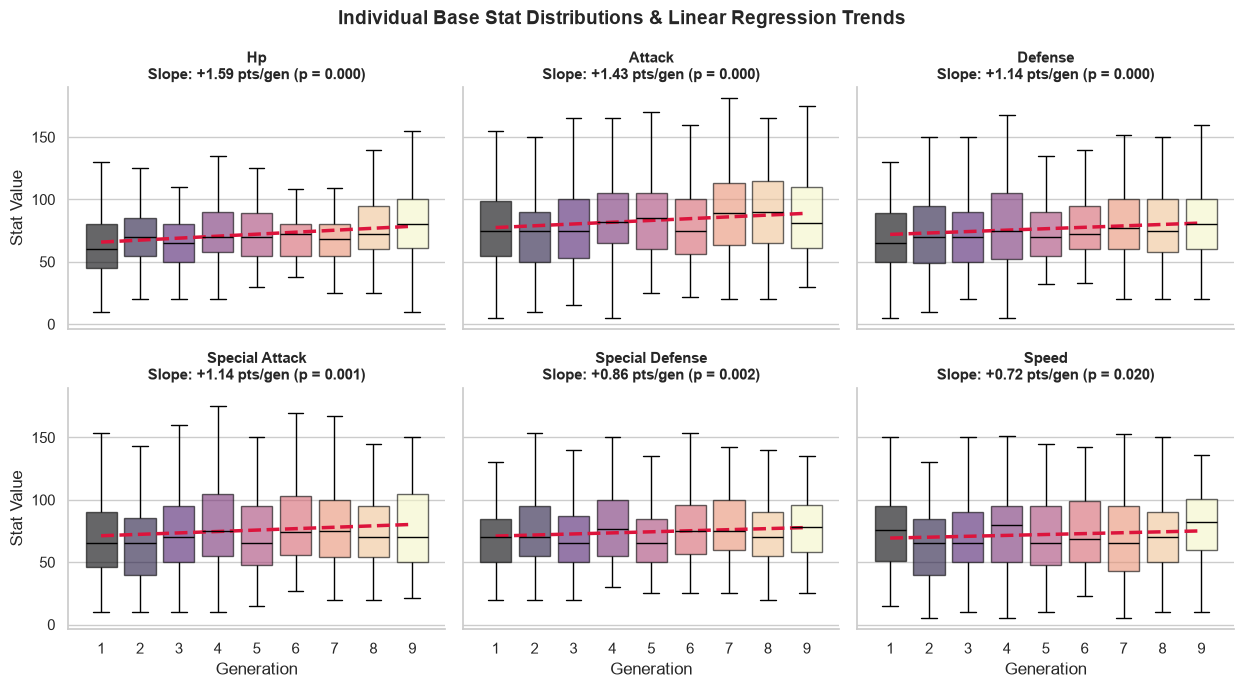

In [ ]:
# Code for Individual Stats vs Generation Number

g = sns.catplot(
    data=df_melted,
    x='gen_num',
    y='stat_value',
    col='stat_type',
    col_wrap=3,
    kind='box',
    hue='gen_num',
    palette='magma',
    legend=False,
    height=3.5,
    aspect=1.2,
    boxprops=dict(alpha=0.6),
    showfliers=False,
)


print("=== LINEAR REGRESSION RESULTS PER INDIVIDUAL STAT ===")

for stat_name, ax in g.axes_dict.items():
    sub_data = df_melted[df_melted['stat_type'] == stat_name]

    slope, intercept, r_val, p_val, std_err = stats.linregress(
        sub_data['gen_num'], sub_data['stat_value']
    )

    print(
        f"{stat_name:<15} | Slope: +{slope:.3f} pts/gen | R²: {r_val**2:.4f} | p-value: {p_val:.4f}"
    )

    gens = np.sort(sub_data['gen_num'].unique())
    x_plot = gens - 1
    y_plot = intercept + slope * gens

    ax.plot(
        x_plot,
        y_plot,
        color='crimson',
        linewidth=2.5,
        linestyle='--',
        label='Regression Trend',
    )

    ax.set_title(
        f'{stat_name}\nSlope: +{slope:.2f} pts/gen (p = {p_val:.3f})',
        fontsize=11,
        fontweight='bold',
    )

g.set_axis_labels('Generation', 'Stat Value')
g.figure.subplots_adjust(top=0.88)
g.figure.suptitle(
    'Individual Base Stat Distributions & Linear Regression Trends',
    fontsize=14,
    fontweight='bold',
)

plt.tight_layout()
plt.show()


### Conclusion

When we look at the 